# mmCRC mOS Distribution

This notebook loads `mmCRC_endpoints.csv` and visualizes the distribution of `mOS_months` across all patients in mmCRC.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import display

DATA_ROOT = Path('/Users/marcalbesa/Desktop/TFM/data/mmCRC')
ENDPOINTS_PATH = DATA_ROOT / 'mmCRC_endpoints.csv'
ID_COL = 'sap'
TARGET_COL = 'mOS_months'

if not ENDPOINTS_PATH.is_file():
    raise FileNotFoundError(f'Could not find mmCRC_endpoints.csv at: {ENDPOINTS_PATH}')


## Load Endpoints Table

Load the patient-level endpoints table and keep only valid `mOS_months` values.


In [2]:
endpoints_df = pd.read_csv(ENDPOINTS_PATH)

required_cols = [ID_COL, TARGET_COL]
missing_cols = [col for col in required_cols if col not in endpoints_df.columns]
if missing_cols:
    raise ValueError(f'mmCRC_endpoints.csv is missing required columns: {missing_cols}')

os_df = endpoints_df[[ID_COL, TARGET_COL]].copy()
os_df[TARGET_COL] = pd.to_numeric(os_df[TARGET_COL], errors='coerce')
os_df = os_df.dropna(subset=[TARGET_COL]).reset_index(drop=True)

print(f'Total patients with valid {TARGET_COL}: {len(os_df)}')
print(f'Min {TARGET_COL}: {os_df[TARGET_COL].min():.3f}')
print(f'Max {TARGET_COL}: {os_df[TARGET_COL].max():.3f}')
print(f'Mean {TARGET_COL}: {os_df[TARGET_COL].mean():.3f}')
print(f'Median {TARGET_COL}: {os_df[TARGET_COL].median():.3f}')
print()
print(f'=== {TARGET_COL} summary ===')
display(os_df[TARGET_COL].describe().to_frame(name=TARGET_COL))


Total patients with valid mOS_months: 165
Min mOS_months: 0.197
Max mOS_months: 127.431
Mean mOS_months: 28.961
Median mOS_months: 21.419

=== mOS_months summary ===


,mOS_months
count,165.000000
mean,28.960698
std,25.100990
min,0.197109
25%,11.629435
50%,21.419185
75%,39.717477
max,127.431012


## Plot Distribution

Histogram with mean and median lines, plus a boxplot to inspect spread and outliers.


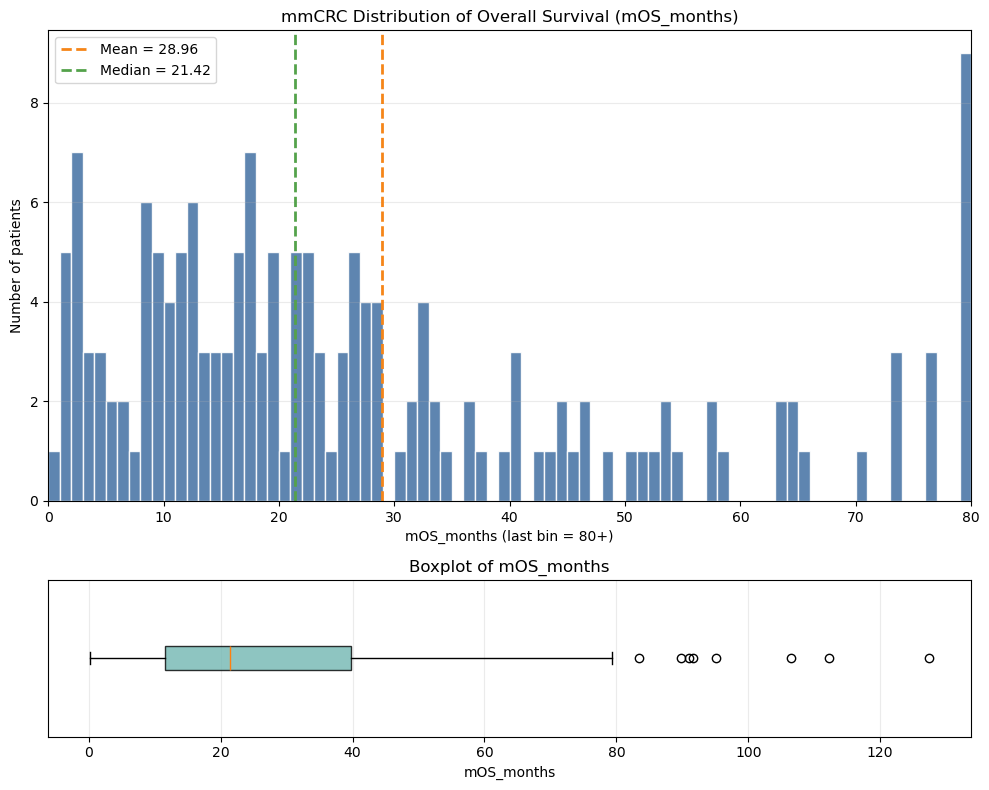

In [3]:
import matplotlib.pyplot as plt

values = os_df[TARGET_COL].to_numpy(dtype=float)
mean_value = float(np.mean(values))
median_value = float(np.median(values))
hist_cap = 80.0
hist_values = np.minimum(values, hist_cap)

fig, axes = plt.subplots(2, 1, figsize=(10, 8), gridspec_kw={'height_ratios': [3, 1]})

month_bins = np.arange(np.floor(values.min()), hist_cap + 1, 1.0)
axes[0].hist(hist_values, bins=month_bins, color='#4C78A8', edgecolor='white', alpha=0.9)
axes[0].set_xlim(np.floor(values.min()), hist_cap)
axes[0].axvline(mean_value, color='#F58518', linestyle='--', linewidth=2, label=f'Mean = {mean_value:.2f}')
axes[0].axvline(median_value, color='#54A24B', linestyle='--', linewidth=2, label=f'Median = {median_value:.2f}')
axes[0].set_title('mmCRC Distribution of Overall Survival (mOS_months)')
axes[0].set_xlabel('mOS_months (last bin = 80+)')
axes[0].set_ylabel('Number of patients')
axes[0].grid(axis='y', alpha=0.25)
axes[0].legend()

axes[1].boxplot(values, vert=False, patch_artist=True, boxprops={'facecolor': '#72B7B2', 'alpha': 0.8})
axes[1].set_xlabel('mOS_months')
axes[1].set_yticks([])
axes[1].set_title('Boxplot of mOS_months')
axes[1].grid(axis='x', alpha=0.25)

plt.tight_layout()
plt.show()


## Export Reduced Endpoints Table

Remove patients with `8 < mOS_months < 10` and save the filtered endpoints table as `mmCRC_endpoints_reduced.csv` in the same dataset directory.


In [4]:
REDUCED_ENDPOINTS_PATH = DATA_ROOT / 'mmCRC_endpoints_reduced.csv'

mask_to_remove = (os_df[TARGET_COL] > 8.0) & (os_df[TARGET_COL] < 10.0)
patients_to_remove = set(os_df.loc[mask_to_remove, ID_COL])
reduced_endpoints_df = endpoints_df.loc[~endpoints_df[ID_COL].isin(patients_to_remove)].copy()
reduced_endpoints_df.to_csv(REDUCED_ENDPOINTS_PATH, index=False)

print(f'Original rows: {len(endpoints_df)}')
print(f'Removed rows: {len(endpoints_df) - len(reduced_endpoints_df)}')
print(f'Reduced rows: {len(reduced_endpoints_df)}')
print(f'Saved reduced dataset to: {REDUCED_ENDPOINTS_PATH}')


Original rows: 165
Removed rows: 11
Reduced rows: 154
Saved reduced dataset to: /Users/marcalbesa/Desktop/TFM/data/mmCRC/mmCRC_endpoints_reduced.csv
